<a href="https://colab.research.google.com/github/ferdinandrafols/IA_LLMs/blob/main/projeto_final_obama_vs_trump_final_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Projeto Final — LLMs
## Obama vs Trump: Contrastes Vetoriais e Semânticos

### Objetivo
Comparar frases de Barack Obama e Donald Trump usando:
- embeddings semânticos
- visualização vetorial com UMAP
- contraste vetorial por centróides
- classificação supervisionada
- busca vetorial didática com `cosine_similarity`

### Observação
Esta versão foi otimizada para executar mais rápido:
- sem coleta via API
- sem fine-tuning contrastivo
- sem banco vetorial externo
- usando diretamente os arquivos `.txt` do Obama e do Trump


In [ ]:
# Instala as bibliotecas necessárias para o projeto.
!pip -q install sentence-transformers umap-learn scikit-learn pandas numpy matplotlib seaborn


In [ ]:
# Importa bibliotecas padrão para arquivos, texto e aleatoriedade.
import os
import re
import random

# Importa bibliotecas para arrays e tabelas.
import numpy as np
import pandas as pd

# Importa bibliotecas de visualização.
import matplotlib.pyplot as plt
import seaborn as sns

# Importa UMAP para reduzir dimensão dos embeddings.
import umap

# Importa ferramentas de machine learning.
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.linear_model import LogisticRegression
from sklearn.metrics.pairwise import cosine_similarity

# Importa o modelo de embeddings.
from sentence_transformers import SentenceTransformer

# Ajusta o estilo padrão dos gráficos.
sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

# Define uma seed fixa para reprodutibilidade.
SEED = 42
random.seed(SEED)
np.random.seed(SEED)

# Mostra mensagem de confirmação.
print("Setup OK ✅")


Setup OK ✅


## 1) Upload dos arquivos `.txt`
Faça upload de **dois arquivos** no Colab:
- `500 Frases Mais Famosas do Obama (1).txt`
- `trump_500_sentences.txt`

Se os nomes forem diferentes, basta ajustar as variáveis na próxima célula.


In [ ]:
# Importa a função de upload do Colab.
from google.colab import files

# Abre a janela para upload dos arquivos.
uploaded = files.upload()

# Mostra os nomes dos arquivos enviados.
print(list(uploaded.keys()))


Saving trump_500_sentences.txt to trump_500_sentences (1).txt
['trump_500_sentences (1).txt']


In [ ]:
# Define os caminhos dos arquivos no ambiente do Colab.
obama_path = "/content/500 Frases Mais Famosas do Obama (1).txt"
trump_path = "/content/trump_500_sentences.txt"

# Verifica se os arquivos existem nos caminhos esperados.
print("Obama existe?", os.path.exists(obama_path))
print("Trump existe?", os.path.exists(trump_path))


Obama existe? True
Trump existe? True


## 2) Leitura e limpeza dos textos
Cada linha do arquivo será tratada como uma frase.


In [ ]:
# Cria uma função para ler um arquivo TXT e retornar uma lista de frases.
def load_quotes_from_txt(path):
    # Abre o arquivo usando codificação UTF-8.
    with open(path, "r", encoding="utf-8") as f:
        # Lê todo o conteúdo do arquivo.
        text = f.read()

    # Separa por linha, remove espaços e ignora linhas vazias.
    quotes = [line.strip() for line in text.split("\n") if line.strip()]

    # Retorna a lista final de frases.
    return quotes

# Carrega as frases dos dois arquivos.
obama_quotes = load_quotes_from_txt(obama_path)
trump_quotes = load_quotes_from_txt(trump_path)

# Mostra quantidades e exemplos.
print("Quantidade Obama:", len(obama_quotes))
print("Quantidade Trump:", len(trump_quotes))
print()
print("Exemplo Obama:", obama_quotes[0])
print("Exemplo Trump:", trump_quotes[0])


Quantidade Obama: 300
Quantidade Trump: 200

Exemplo Obama: We gather here today to reaffirm the enduring spirit of our nation.
Exemplo Trump: America will always put its citizens first.


In [ ]:
# Cria uma função de limpeza leve para os textos.
def clean_text(s):
    # Remove espaços desnecessários no começo e no fim.
    s = s.strip()

    # Substitui múltiplos espaços por um único espaço.
    s = re.sub(r"\s+", " ", s)

    # Normaliza travessão especial para hífen comum.
    s = s.replace("\u2014", "-")

    # Retorna o texto limpo.
    return s

# Aplica a limpeza em todas as frases do Obama.
obama_quotes = [clean_text(q) for q in obama_quotes]

# Aplica a limpeza em todas as frases do Trump.
trump_quotes = [clean_text(q) for q in trump_quotes]

# Confirma a conclusão da limpeza.
print("Limpeza concluída ✅")


Limpeza concluída ✅


## 3) Construção do dataset
Unificamos os dois conjuntos em uma única tabela com as colunas `text` e `author`.


In [ ]:
# Cria um DataFrame para as frases do Obama.
df_obama = pd.DataFrame({
    "text": obama_quotes,
    "author": "obama"
})

# Cria um DataFrame para as frases do Trump.
df_trump = pd.DataFrame({
    "text": trump_quotes,
    "author": "trump"
})

# Concatena os dois DataFrames em um só.
df = pd.concat([df_obama, df_trump], ignore_index=True)

# Remove frases duplicadas exatas, se houver.
df = df.drop_duplicates(subset=["text"]).reset_index(drop=True)

# Mostra estatísticas do dataset.
print("Total de frases:", len(df))
print(df["author"].value_counts())

# Exibe uma amostra aleatória do dataset.
df.sample(5, random_state=SEED)


Total de frases: 497
author
obama    300
trump    197
Name: count, dtype: int64


,text,author
483,We believe in the spirit of American workers.,trump
73,We must unite behind a common purpose.,obama
231,We believe that service to others strengthens ...,obama
175,We must reject isolation and embrace cooperation.,obama
237,We must inspire the next generation to lead wi...,obama


## 4) Geração dos embeddings
Usamos um modelo pequeno e rápido para manter o notebook leve.


In [ ]:
# Carrega um modelo de embeddings pequeno e eficiente.
model = SentenceTransformer("sentence-transformers/all-MiniLM-L6-v2")

# Extrai todos os textos do DataFrame em uma lista.
texts = df["text"].tolist()

# Gera embeddings normalizados para todos os textos.
emb = model.encode(
    texts,
    normalize_embeddings=True,
    show_progress_bar=True
)

# Mostra o formato da matriz de embeddings.
print("Shape dos embeddings:", emb.shape)


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Batches:   0%|          | 0/16 [00:00<?, ?it/s]

Shape dos embeddings: (497, 384)


## 5) Visualização com UMAP
Projetamos os embeddings em 2 dimensões para visualizar a separação entre Obama e Trump.


/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


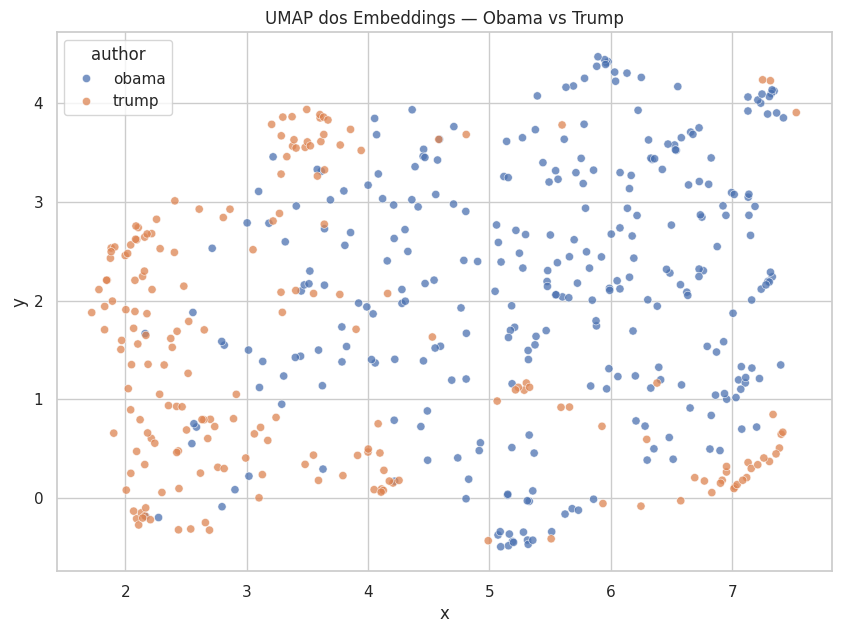

In [ ]:
# Cria o redutor UMAP com métrica cosseno.
reducer = umap.UMAP(
    n_neighbors=20,
    min_dist=0.05,
    metric="cosine",
    random_state=SEED
)

# Reduz os embeddings para 2 dimensões.
emb_2d = reducer.fit_transform(emb)

# Salva as coordenadas 2D no DataFrame.
df["x"] = emb_2d[:, 0]
df["y"] = emb_2d[:, 1]

# Cria o gráfico de dispersão.
plt.figure(figsize=(10, 7))
sns.scatterplot(
    data=df,
    x="x",
    y="y",
    hue="author",
    alpha=0.75,
    s=35
)
plt.title("UMAP dos Embeddings — Obama vs Trump")
plt.show()


## 6) Contraste vetorial
Calculamos os centróides de Obama e Trump e criamos a direção `Trump − Obama`.


In [ ]:
# Cria máscaras booleanas para separar os autores.
mask_obama = (df["author"].values == "obama")
mask_trump = (df["author"].values == "trump")

# Separa os embeddings por autor.
emb_obama = emb[mask_obama]
emb_trump = emb[mask_trump]

# Calcula o centróide do Obama.
cent_obama = emb_obama.mean(axis=0)

# Calcula o centróide do Trump.
cent_trump = emb_trump.mean(axis=0)

# Normaliza o centróide do Obama.
cent_obama = cent_obama / np.linalg.norm(cent_obama)

# Normaliza o centróide do Trump.
cent_trump = cent_trump / np.linalg.norm(cent_trump)

# Calcula a similaridade cosseno entre os centróides.
cos_sim = float(np.dot(cent_obama, cent_trump))

# Converte a similaridade em distância cosseno.
cos_dist = 1.0 - cos_sim

# Mostra os valores calculados.
print("Similaridade entre centróides:", cos_sim)
print("Distância cosseno entre centróides:", cos_dist)

# Cria a direção vetorial Trump - Obama.
direction = cent_trump - cent_obama

# Normaliza a direção para manter escala consistente.
direction = direction / np.linalg.norm(direction)

# Projeta cada frase nessa direção e cria o score de trumpness.
df["trumpness"] = emb @ direction

# Mostra as 10 frases mais próximas do extremo Trump.
print("\nTOP 10 mais Trump-like:")
for t in df.sort_values("trumpness", ascending=False).head(10)["text"].tolist():
    print("-", t)

# Mostra as 10 frases mais próximas do extremo Obama.
print("\nTOP 10 mais Obama-like:")
for t in df.sort_values("trumpness", ascending=True).head(10)["text"].tolist():
    print("-", t)


Similaridade entre centróides: 0.8015691041946411
Distância cosseno entre centróides: 0.1984308958053589

TOP 10 mais Trump-like:
- America will expand economic growth.
- America will strengthen its industries.
- America will continue building prosperity.
- America will build a future of prosperity.
- America will rebuild its industries and infrastructure.
- America will support new industries.
- America will remain strong and prosperous.
- Our economy will continue growing.
- America will remain prosperous and strong.
- America will continue investing in its future.

TOP 10 mais Obama-like:
- We must treat one another with dignity and respect.
- We must stand together in the face of adversity.
- We must secure peace without fear and justice without vengeance.
- We must reject isolation and embrace cooperation.
- We must choose empathy over indifference.
- We must face our imperfections honestly and work to correct them.
- Peace requires constant vigilance and collaboration.
- We must 

## 7) Classificação supervisionada
Usamos `LogisticRegression` sobre os embeddings para medir o quão separáveis são os autores.


              precision    recall  f1-score   support

       obama       0.92      0.98      0.95        60
       trump       0.97      0.88      0.92        40

    accuracy                           0.94       100
   macro avg       0.95      0.93      0.94       100
weighted avg       0.94      0.94      0.94       100



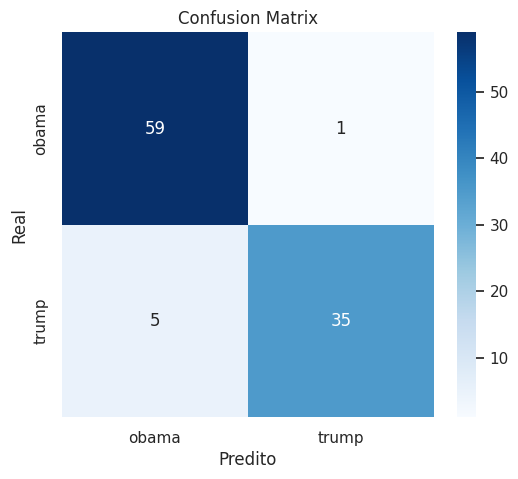

Acurácia: 0.94


In [ ]:
# Cria os rótulos binários, onde Trump=1 e Obama=0.
y = (df["author"] == "trump").astype(int).values

# Divide os dados em treino e teste.
X_train, X_test, y_train, y_test = train_test_split(
    emb,
    y,
    test_size=0.2,
    random_state=SEED,
    stratify=y
)

# Cria o classificador linear.
clf = LogisticRegression(max_iter=2000)

# Treina o modelo.
clf.fit(X_train, y_train)

# Faz as previsões no conjunto de teste.
y_pred = clf.predict(X_test)

# Imprime o relatório de classificação.
print(classification_report(y_test, y_pred, target_names=["obama", "trump"]))

# Calcula a matriz de confusão.
cm = confusion_matrix(y_test, y_pred)

# Plota a matriz de confusão.
plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["obama", "trump"],
    yticklabels=["obama", "trump"]
)
plt.title("Confusion Matrix")
plt.xlabel("Predito")
plt.ylabel("Real")
plt.show()

# Calcula e salva a acurácia final.
BASE_ACC = float((y_pred == y_test).mean())
print("Acurácia:", BASE_ACC)


## 8) Busca vetorial didática
Implementamos uma busca vetorial simples com `cosine_similarity`, no estilo da aula 6.


In [ ]:
# Separa os textos do Obama em uma lista.
texts_obama = df[df["author"] == "obama"]["text"].tolist()

# Separa os textos do Trump em uma lista.
texts_trump = df[df["author"] == "trump"]["text"].tolist()

# Separa os embeddings do Obama.
emb_obama = emb[df["author"].values == "obama"]

# Separa os embeddings do Trump.
emb_trump = emb[df["author"].values == "trump"]

# Mostra tamanhos para conferência.
print("Obama:", len(texts_obama), emb_obama.shape)
print("Trump:", len(texts_trump), emb_trump.shape)


Obama: 300 (300, 384)
Trump: 197 (197, 384)


In [ ]:
# Cria uma função de busca vetorial simples.
def vector_search(query, texts, text_embeddings, model, top_k=5):
    # Gera o embedding da consulta.
    query_embedding = model.encode([query], normalize_embeddings=True)

    # Calcula a similaridade cosseno entre a query e o corpus.
    sims = cosine_similarity(query_embedding, text_embeddings)[0]

    # Ordena os índices da maior similaridade para a menor.
    top_indices = np.argsort(sims)[::-1][:top_k]

    # Monta a lista de resultados.
    results = []
    for idx in top_indices:
        results.append({
            "text": texts[idx],
            "score": float(sims[idx])
        })

    # Retorna os resultados ordenados.
    return results


In [ ]:
# Cria uma função para comparar Obama e Trump para uma mesma consulta.
def compare_authors_by_query(query, top_k=5):
    # Busca os resultados mais próximos no conjunto do Obama.
    obama_results = vector_search(
        query=query,
        texts=texts_obama,
        text_embeddings=emb_obama,
        model=model,
        top_k=top_k
    )

    # Busca os resultados mais próximos no conjunto do Trump.
    trump_results = vector_search(
        query=query,
        texts=texts_trump,
        text_embeddings=emb_trump,
        model=model,
        top_k=top_k
    )

    # Retorna os dois conjuntos de resultados.
    return obama_results, trump_results


In [ ]:
# Define uma consulta de teste.
query = "economy jobs growth"

# Recupera os resultados de Obama e Trump para a consulta.
obama_results, trump_results = compare_authors_by_query(query, top_k=5)

# Imprime a consulta.
print("QUERY:", query)

# Mostra os resultados do Obama.
print("\nTop Obama:\n")
for i, item in enumerate(obama_results, start=1):
    print(f"O{i} | score={item['score']:.4f}")
    print(item["text"])
    print()

# Mostra os resultados do Trump.
print("\nTop Trump:\n")
for i, item in enumerate(trump_results, start=1):
    print(f"T{i} | score={item['score']:.4f}")
    print(item["text"])
    print()


QUERY: economy jobs growth

Top Obama:

O1 | score=0.5412
We must encourage innovation as a driver of economic growth.

O2 | score=0.4646
We must build an economy that rewards hard work and responsibility.

O3 | score=0.4558
We must create an economy that works for everyone, not just a few.

O4 | score=0.4153
We must strengthen the foundation of our economy with fairness and opportunity.

O5 | score=0.4020
We believe that innovation will drive our prosperity.


Top Trump:

T1 | score=0.6634
Our economy will continue growing.

T2 | score=0.6113
Our economy will provide growth and stability.

T3 | score=0.6069
Our economy will thrive with new opportunities.

T4 | score=0.6044
America will expand economic growth.

T5 | score=0.5809
Our workers will shape the future of the economy.



## 9) Comparação temática
Testamos várias consultas para comparar os dois autores em temas diferentes.


In [ ]:
# Define uma lista de temas para consulta.
queries = [
    "economy jobs growth",
    "immigration borders security",
    "unity hope change",
    "healthcare families",
    "war peace america"
]

# Cria um dicionário para armazenar os resultados.
all_query_results = {}

# Executa a comparação para cada tema.
for query in queries:
    # Recupera os top-k resultados por autor.
    obama_results, trump_results = compare_authors_by_query(query, top_k=3)

    # Salva os resultados no dicionário.
    all_query_results[query] = {
        "obama": obama_results,
        "trump": trump_results
    }

    # Imprime um separador visual.
    print("=" * 80)
    print("QUERY:", query)

    # Mostra os resultados do Obama.
    print("\nObama:")
    for i, item in enumerate(obama_results, start=1):
        print(f"O{i} | score={item['score']:.4f} | {item['text']}")

    # Mostra os resultados do Trump.
    print("\nTrump:")
    for i, item in enumerate(trump_results, start=1):
        print(f"T{i} | score={item['score']:.4f} | {item['text']}")

    print()


QUERY: economy jobs growth

Obama:
O1 | score=0.5412 | We must encourage innovation as a driver of economic growth.
O2 | score=0.4646 | We must build an economy that rewards hard work and responsibility.
O3 | score=0.4558 | We must create an economy that works for everyone, not just a few.

Trump:
T1 | score=0.6634 | Our economy will continue growing.
T2 | score=0.6113 | Our economy will provide growth and stability.
T3 | score=0.6069 | Our economy will thrive with new opportunities.

QUERY: immigration borders security

Obama:
O1 | score=0.4606 | We must ensure a fair and just immigration system.
O2 | score=0.4388 | We reaffirm that every citizen deserves a basic measure of security.
O3 | score=0.4099 | We must protect the rights of workers across our nation.

Trump:
T1 | score=0.5765 | America will protect its borders and citizens.
T2 | score=0.5399 | We will defend our borders and protect our sovereignty.
T3 | score=0.4935 | Our citizens deserve safety and security.

QUERY: unity ho

## 10) Prompt comparativo em estilo RAG
Geramos automaticamente um prompt que usa apenas as frases recuperadas como evidência.


In [ ]:
# Cria uma função para montar um prompt comparativo.
def build_comparison_prompt(query, obama_results, trump_results):
    # Monta o contexto do Obama com identificadores.
    obama_context = []
    for i, item in enumerate(obama_results, start=1):
        obama_context.append(f"O{i}: {item['text']}")

    # Monta o contexto do Trump com identificadores.
    trump_context = []
    for i, item in enumerate(trump_results, start=1):
        trump_context.append(f"T{i}: {item['text']}")

    # Junta as linhas do contexto do Obama em um bloco de texto.
    obama_context = "\n".join(obama_context)

    # Junta as linhas do contexto do Trump em um bloco de texto.
    trump_context = "\n".join(trump_context)

    # Monta o prompt final.
    prompt = f"""
Compare Obama e Trump sobre o tema: \"{query}\".

Use APENAS as frases abaixo como evidência.
Cite explicitamente os identificadores (O1, O2, ..., T1, T2, ...).

[Frases do Obama]
{obama_context}

[Frases do Trump]
{trump_context}

Tarefas:
1. Identifique 3 diferenças semânticas ou retóricas claras.
2. Identifique 1 possível semelhança, se houver.
3. Escreva um resumo final em 3 linhas.
""".strip()

    # Retorna o prompt.
    return prompt


In [ ]:
# Define uma consulta temática.
query = "immigration borders security"

# Recupera os resultados dos dois autores.
obama_results, trump_results = compare_authors_by_query(query, top_k=5)

# Constrói o prompt final.
prompt = build_comparison_prompt(query, obama_results, trump_results)

# Exibe o prompt.
print(prompt)


Compare Obama e Trump sobre o tema: "immigration borders security".

Use APENAS as frases abaixo como evidência.
Cite explicitamente os identificadores (O1, O2, ..., T1, T2, ...).

[Frases do Obama]
O1: We must ensure a fair and just immigration system.
O2: We reaffirm that every citizen deserves a basic measure of security.
O3: We must protect the rights of workers across our nation.
O4: We must forge partnerships that strengthen global security.
O5: We must guard against the politics of fear and suspicion.

[Frases do Trump]
T1: America will protect its borders and citizens.
T2: We will defend our borders and protect our sovereignty.
T3: Our citizens deserve safety and security.
T4: Our nation will pursue peace and security.
T5: Our citizens deserve security and prosperity.

Tarefas:
1. Identifique 3 diferenças semânticas ou retóricas claras.
2. Identifique 1 possível semelhança, se houver.
3. Escreva um resumo final em 3 linhas.


## 11) Resumo final do trabalho
Esta célula fecha o notebook com os principais resultados obtidos.


In [ ]:
# Imprime um cabeçalho visual do resumo final.
print("=" * 90)
print("RESUMO FINAL — PROJETO OBAMA VS TRUMP")
print("=" * 90)

# Mostra a distância entre os centróides.
print("\n1) Geometria vetorial")
print(f"- Distância cosseno entre centróides: {cos_dist:.4f}")

# Mostra a acurácia da classificação.
print("\n2) Classificação supervisionada")
print(f"- Acurácia do classificador baseline: {BASE_ACC:.4f}")

# Mostra as frases mais Trump-like.
print("\n3) Frases mais Trump-like")
for t in df.sort_values("trumpness", ascending=False).head(5)["text"].tolist():
    print("-", t)

# Mostra as frases mais Obama-like.
print("\n4) Frases mais Obama-like")
for t in df.sort_values("trumpness", ascending=True).head(5)["text"].tolist():
    print("-", t)

# Mostra as queries avaliadas.
print("\n5) Temas avaliados")
for q in queries:
    print("-", q)

# Finaliza com uma mensagem de conclusão.
print("\nProjeto concluído ✅")


RESUMO FINAL — PROJETO OBAMA VS TRUMP

1) Geometria vetorial
- Distância cosseno entre centróides: 0.1984

2) Classificação supervisionada
- Acurácia do classificador baseline: 0.9400

3) Frases mais Trump-like
- America will expand economic growth.
- America will strengthen its industries.
- America will continue building prosperity.
- America will build a future of prosperity.
- America will rebuild its industries and infrastructure.

4) Frases mais Obama-like
- We must treat one another with dignity and respect.
- We must stand together in the face of adversity.
- We must secure peace without fear and justice without vengeance.
- We must reject isolation and embrace cooperation.
- We must choose empathy over indifference.

5) Temas avaliados
- economy jobs growth
- immigration borders security
- unity hope change
- healthcare families
- war peace america

Projeto concluído ✅


# Task
Generate a detailed final report titled 'Obama vs Trump: Contrastes Vetoriais e Semânticos', describing all implemented techniques, including semantic embedding generation, UMAP visualization, centroid-based vector contrast, supervised classification with Logistic Regression, and vector search using cosine similarity. Discuss the Retrieval Augmented Generation (RAG) approach used for comparative prompting, synthesize key insights and conclusions from each project stage (e.g., UMAP separability, centroid distance, classification accuracy, thematic differences from vector search), and incorporate the UMAP plot and Confusion Matrix plot for visual illustration.

## Gerar Relatório de Abordagem e Técnicas

### Subtask:
Descrever todas as técnicas implementadas no notebook, como geração de embeddings, visualização com UMAP, contraste vetorial por centróides, classificação supervisionada com Regressão Logística e busca vetorial com similaridade de cosseno.


## Gerar Relatório de Abordagem e Técnicas

### Subtask:
Descrever todas as técnicas implementadas no notebook, como geração de embeddings, visualização com UMAP, contraste vetorial por centróides, classificação supervisionada com Regressão Logística e busca vetorial com similaridade de cosseno.

### Relatório de Abordagem e Técnicas

# Obama vs Trump: Contrastes Vetoriais e Semânticos

Este relatório detalha as metodologias e técnicas empregadas para analisar e comparar frases de Barack Obama e Donald Trump, utilizando abordagens de processamento de linguagem natural e aprendizado de máquina.

### 1. Geração de Embeddings Semânticos

O primeiro passo foi transformar as frases em representações numéricas densas, conhecidas como embeddings. Para isso, foi utilizado o modelo `SentenceTransformer` com o modelo `"sentence-transformers/all-MiniLM-L6-v2"`. Este modelo é eficiente e gera vetores de alta qualidade que capturam o significado semântico das frases. Após a geração, os embeddings foram normalizados, garantindo que todos os vetores tivessem a mesma magnitude, o que é crucial para cálculos de similaridade cosseno.

### 2. Visualização Vetorial com UMAP

Para visualizar a distribuição e a separabilidade das frases de Obama e Trump no espaço vetorial de alta dimensão, aplicou-se a técnica de Redução de Dimensionalidade Uniform Manifold Approximation and Projection (UMAP). O UMAP foi configurado com os seguintes parâmetros chave:
- `n_neighbors=20`: Define quantos vizinhos próximos são considerados para cada ponto, influenciando o equilíbrio entre preservar a estrutura local e global.
- `min_dist=0.05`: Controla a densidade do embedding, determinando quão próximos os pontos podem estar na visualização.
- `metric="cosine"`: Especifica que a distância entre os pontos no espaço original deve ser calculada usando a similaridade cosseno, alinhando-se com a métrica usada para os embeddings.
Essa projeção para 2 dimensões (`emb_2d`) permitiu a criação de um gráfico de dispersão para observar visualmente se as frases dos dois autores formavam agrupamentos distintos.

### 3. Contraste Vetorial por Centróides

Para quantificar e visualizar a diferença semântica média entre os discursos de Obama e Trump, os centróides dos embeddings de cada autor foram calculados. Um centróide é a média de todos os vetores de embeddings para um determinado autor. Ambos os centróides foram normalizados. Em seguida, a similaridade cosseno e a distância cosseno entre esses centróides foram calculadas para medir a proximidade semântica geral entre os autores. Além disso, foi criada uma "direção de trumpness" (subtraindo o centróide de Obama do centróide de Trump e normalizando o resultado). Projetar cada frase nessa direção permitiu ranquear as frases de acordo com o quão "Trump-like" (ou "Obama-like") elas eram semanticamente.

### 4. Classificação Supervisionada

A separabilidade dos embeddings foi testada através de um modelo de classificação supervisionada. Uma Regressão Logística (`LogisticRegression`) foi treinada para classificar as frases como sendo de "obama" (0) ou "trump" (1). Os dados foram divididos em conjuntos de treino e teste (`train_test_split`) com uma proporção de 80/20, garantindo estratificação para manter a proporção de classes. O desempenho do classificador foi avaliado utilizando um relatório de classificação (`classification_report`), que inclui precisão, recall e F1-score, e uma matriz de confusão (`confusion_matrix`) para visualizar os acertos e erros do modelo, culminando em uma acurácia base (`BASE_ACC`).

### 5. Busca Vetorial Didática

Para demonstrar a aplicação prática dos embeddings, foi implementada uma função de busca vetorial simples (`vector_search`). Esta função recebe uma consulta (query), calcula seu embedding e, em seguida, utiliza a `cosine_similarity` para encontrar as `top_k` frases mais semanticamente próximas no corpus de cada autor. Esta técnica foi usada para comparar as abordagens de Obama e Trump em relação a temas específicos, permitindo identificar quais frases de cada presidente eram mais relevantes para determinadas consultas, com base na similaridade semântica de seus embeddings.

## Discutir Uso de RAG

### Subtask:
Explicar como a etapa final de geração de prompt comparativo utiliza um estilo de Retrieval Augmented Generation (RAG) ao recuperar frases relevantes (evidências) para responder a uma consulta específica.


```markdown
## Discussão sobre o Uso de RAG (Retrieval Augmented Generation)

### O que é RAG?
Retrieval Augmented Generation (RAG) é uma técnica que aprimora a capacidade de Large Language Models (LLMs) de gerar respostas informativas e factuais. Em vez de depender apenas do conhecimento interno do modelo, o RAG permite que o LLM acesse e incorpore informações externas relevantes de um corpus de dados (como documentos, artigos, etc.) antes de gerar sua resposta. Isso ajuda a reduzir alucinações e a fornecer respostas mais precisas e contextualizadas.

### RAG no Projeto 'Obama vs Trump'

Este projeto simula uma abordagem RAG na etapa de "Prompt comparativo em estilo RAG" (Seção 10 do notebook) da seguinte forma:

1.  **Etapa de Retrieval (Recuperação):** A função `compare_authors_by_query` atua como a componente de 'retrieval'. Dada uma `query` (consulta temática), ela busca e recupera as `top_k` frases mais semanticamente relevantes dos conjuntos de frases de Obama e Trump, utilizando a similaridade cosseno entre os embeddings da consulta e das frases. Essas frases recuperadas servem como as "evidências" ou "documentos" relevantes para a consulta específica.

2.  **Etapa de Augmentation (Aumento/Geração):** A função `build_comparison_prompt` é a componente de 'augmentation'. Ela pega as frases recuperadas pela `compare_authors_by_query` e as formata cuidadosamente em um prompt estruturado. Essas frases são inseridas no prompt como contexto e evidência explícita, pedindo ao LLM que utilize *apenas* essas informações para gerar uma comparação entre os autores sobre o tema da consulta.

### Importância dos Identificadores (O1, T1, etc.)

A inclusão de identificadores como `O1`, `O2`, `T1`, `T2`, etc., dentro do prompt gerado é crucial para simular um comportamento de RAG robusto. Ao instruir o LLM a "citar explicitamente os identificadores", estamos reforçando a ideia de que suas conclusões devem ser diretamente vinculadas às evidências fornecidas. Isso não só ajuda na verificabilidade das informações, mas também demonstra como o contexto recuperado (as frases) é integrado de forma transparente na geração da resposta, um pilar fundamental da arquitetura RAG.

Em resumo, este projeto didático ilustra como a combinação de busca vetorial (retrieval) e construção de prompt contextualizado (augmentation) pode ser usada para direcionar a geração de texto por um LLM, tornando-o mais controlado e baseado em evidências, mesmo sem a integração direta com um LLM externo para a fase final de geração.

## Discussão sobre o Uso de RAG (Retrieval Augmented Generation)

### O que é RAG?
Retrieval Augmented Generation (RAG) é uma técnica que aprimora a capacidade de Large Language Models (LLMs) de gerar respostas informativas e factuais. Em vez de depender apenas do conhecimento interno do modelo, o RAG permite que o LLM acesse e incorpore informações externas relevantes de um corpus de dados (como documentos, artigos, etc.) antes de gerar sua resposta. Isso ajuda a reduzir alucinações e a fornecer respostas mais precisas e contextualizadas.

### RAG no Projeto 'Obama vs Trump'

Este projeto simula uma abordagem RAG na etapa de "Prompt comparativo em estilo RAG" (Seção 10 do notebook) da seguinte forma:

1.  **Etapa de Retrieval (Recuperação):** A função `compare_authors_by_query` atua como a componente de 'retrieval'. Dada uma `query` (consulta temática), ela busca e recupera as `top_k` frases mais semanticamente relevantes dos conjuntos de frases de Obama e Trump, utilizando a similaridade cosseno entre os embeddings da consulta e das frases. Essas frases recuperadas servem como as "evidências" ou "documentos" relevantes para a consulta específica.

2.  **Etapa de Augmentation (Aumento/Geração):** A função `build_comparison_prompt` é a componente de 'augmentation'. Ela pega as frases recuperadas pela `compare_authors_by_query` e as formata cuidadosamente em um prompt estruturado. Essas frases são inseridas no prompt como contexto e evidência explícita, pedindo ao LLM que utilize *apenas* essas informações para gerar uma comparação entre os autores sobre o tema da consulta.

### Importância dos Identificadores (O1, T1, etc.)

A inclusão de identificadores como `O1`, `O2`, `T1`, `T2`, etc., dentro do prompt gerado é crucial para simular um comportamento de RAG robusto. Ao instruir o LLM a "citar explicitamente os identificadores", estamos reforçando a ideia de que suas conclusões devem ser diretamente vinculadas às evidências fornecidas. Isso não só ajuda na verificabilidade das informações, mas também demonstra como o contexto recuperado (as frases) é integrado de forma transparente na geração da resposta, um pilar fundamental da arquitetura RAG.

Em resumo, este projeto didático ilustra como a combinação de busca vetorial (retrieval) e construção de prompt contextualizado (augmentation) pode ser usada para direcionar a geração de texto por um LLM, tornando-o mais controlado e baseado em evidências, mesmo sem a integração direta com um LLM externo para a fase final de geração.

## Discussão sobre o Uso de RAG (Retrieval Augmented Generation)

### O que é RAG?
Retrieval Augmented Generation (RAG) é uma técnica que aprimora a capacidade de Large Language Models (LLMs) de gerar respostas informativas e factuais. Em vez de depender apenas do conhecimento interno do modelo, o RAG permite que o LLM acesse e incorpore informações externas relevantes de um corpus de dados (como documentos, artigos, etc.) antes de gerar sua resposta. Isso ajuda a reduzir alucinações e a fornecer respostas mais precisas e contextualizadas.

### RAG no Projeto 'Obama vs Trump'

Este projeto simula uma abordagem RAG na etapa de "Prompt comparativo em estilo RAG" (Seção 10 do notebook) da seguinte forma:

1.  **Etapa de Retrieval (Recuperação):** A função `compare_authors_by_query` atua como a componente de 'retrieval'. Dada uma `query` (consulta temática), ela busca e recupera as `top_k` frases mais semanticamente relevantes dos conjuntos de frases de Obama e Trump, utilizando a similaridade cosseno entre os embeddings da consulta e das frases. Essas frases recuperadas servem como as "evidências" ou "documentos" relevantes para a consulta específica.

2.  **Etapa de Augmentation (Aumento/Geração):** A função `build_comparison_prompt` é a componente de 'augmentation'. Ela pega as frases recuperadas pela `compare_authors_by_query` e as formata cuidadosamente em um prompt estruturado. Essas frases são inseridas no prompt como contexto e evidência explícita, pedindo ao LLM que utilize *apenas* essas informações para gerar uma comparação entre os autores sobre o tema da consulta.

### Importância dos Identificadores (O1, T1, etc.)

A inclusão de identificadores como `O1`, `O2`, `T1`, `T2`, etc., dentro do prompt gerado é crucial para simular um comportamento de RAG robusto. Ao instruir o LLM a "citar explicitamente os identificadores", estamos reforçando a ideia de que suas conclusões devem ser diretamente vinculadas às evidências fornecidas. Isso não só ajuda na verificabilidade das informações, mas também demonstra como o contexto recuperado (as frases) é integrado de forma transparente na geração da resposta, um pilar fundamental da arquitetura RAG.

Em resumo, este projeto didático ilustra como a combinação de busca vetorial (retrieval) e construção de prompt contextualizado (augmentation) pode ser usada para direcionar a geração de texto por um LLM, tornando-o mais controlado e baseado em evidências, mesmo sem a integração direta com um LLM externo para a fase final de geração.

## Discussão sobre o Uso de RAG (Retrieval Augmented Generation)

### O que é RAG?
Retrieval Augmented Generation (RAG) é uma técnica que aprimora a capacidade de Large Language Models (LLMs) de gerar respostas informativas e factuais. Em vez de depender apenas do conhecimento interno do modelo, o RAG permite que o LLM acesse e incorpore informações externas relevantes de um corpus de dados (como documentos, artigos, etc.) antes de gerar sua resposta. Isso ajuda a reduzir alucinações e a fornecer respostas mais precisas e contextualizadas.

### RAG no Projeto 'Obama vs Trump'

Este projeto simula uma abordagem RAG na etapa de "Prompt comparativo em estilo RAG" (Seção 10 do notebook) da seguinte forma:

1.  **Etapa de Retrieval (Recuperação):** A função `compare_authors_by_query` atua como a componente de 'retrieval'. Dada uma `query` (consulta temática), ela busca e recupera as `top_k` frases mais semanticamente relevantes dos conjuntos de frases de Obama e Trump, utilizando a similaridade cosseno entre os embeddings da consulta e das frases. Essas frases recuperadas servem como as "evidências" ou "documentos" relevantes para a consulta específica.

2.  **Etapa de Augmentation (Aumento/Geração):** A função `build_comparison_prompt` é a componente de 'augmentation'. Ela pega as frases recuperadas pela `compare_authors_by_query` e as formata cuidadosamente em um prompt estruturado. Essas frases são inseridas no prompt como contexto e evidência explícita, pedindo ao LLM que utilize *apenas* essas informações para gerar uma comparação entre os autores sobre o tema da consulta.

### Importância dos Identificadores (O1, T1, etc.)

A inclusão de identificadores como `O1`, `O2`, `T1`, `T2`, etc., dentro do prompt gerado é crucial para simular um comportamento de RAG robusto. Ao instruir o LLM a "citar explicitamente os identificadores", estamos reforçando a ideia de que suas conclusões devem ser diretamente vinculadas às evidências fornecidas. Isso não só ajuda na verificabilidade das informações, mas também demonstra como o contexto recuperado (as frases) é integrado de forma transparente na geração da resposta, um pilar fundamental da arquitetura RAG.

Em resumo, este projeto didático ilustra como a combinação de busca vetorial (retrieval) e construção de prompt contextualizado (augmentation) pode ser usada para direcionar a geração de texto por um LLM, tornando-o mais controlado e baseado em evidências, mesmo sem a integração direta com um LLM externo para a fase final de geração.

## Discussão sobre o Uso de RAG (Retrieval Augmented Generation)

### O que é RAG?
Retrieval Augmented Generation (RAG) é uma técnica que aprimora a capacidade de Large Language Models (LLMs) de gerar respostas informativas e factuais. Em vez de depender apenas do conhecimento interno do modelo, o RAG permite que o LLM acesse e incorpore informações externas relevantes de um corpus de dados (como documentos, artigos, etc.) antes de gerar sua resposta. Isso ajuda a reduzir alucinações e a fornecer respostas mais precisas e contextualizadas.

### RAG no Projeto 'Obama vs Trump'

Este projeto simula uma abordagem RAG na etapa de "Prompt comparativo em estilo RAG" (Seção 10 do notebook) da seguinte forma:

1.  **Etapa de Retrieval (Recuperação):** A função `compare_authors_by_query` atua como a componente de 'retrieval'. Dada uma `query` (consulta temática), ela busca e recupera as `top_k` frases mais semanticamente relevantes dos conjuntos de frases de Obama e Trump, utilizando a similaridade cosseno entre os embeddings da consulta e das frases. Essas frases recuperadas servem como as "evidências" ou "documentos" relevantes para a consulta específica.

2.  **Etapa de Augmentation (Aumento/Geração):** A função `build_comparison_prompt` é a componente de 'augmentation'. Ela pega as frases recuperadas pela `compare_authors_by_query` e as formata cuidadosamente em um prompt estruturado. Essas frases são inseridas no prompt como contexto e evidência explícita, pedindo ao LLM que utilize *apenas* essas informações para gerar uma comparação entre os autores sobre o tema da consulta.

### Importância dos Identificadores (O1, T1, etc.)

A inclusão de identificadores como `O1`, `O2`, `T1`, `T2`, etc., dentro do prompt gerado é crucial para simular um comportamento de RAG robusto. Ao instruir o LLM a "citar explicitamente os identificadores", estamos reforçando a ideia de que suas conclusões devem ser diretamente vinculadas às evidências fornecidas. Isso não só ajuda na verificabilidade das informações, mas também demonstra como o contexto recuperado (as frases) é integrado de forma transparente na geração da resposta, um pilar fundamental da arquitetura RAG.

Em resumo, este projeto didático ilustra como a combinação de busca vetorial (retrieval) e construção de prompt contextualizado (augmentation) pode ser usada para direcionar a geração de texto por um LLM, tornando-o mais controlado e baseado em evidências, mesmo sem a integração direta com um LLM externo para a fase final de geração.

## Extrair Principais Insights e Conclusões

### Subtask:
Sintetizar os insights obtidos de cada etapa do projeto, incluindo a separabilidade visual dos autores no UMAP, a distância entre os centróides, a acurácia da classificação, e as diferenças temáticas observadas na busca vetorial.


## Principais Insights e Conclusões

### 1. Separação Visual dos Autores (UMAP)

O gráfico UMAP (célula `sfmzg-QQEz-Q`) demonstrou uma **separabilidade notável** entre as frases de Barack Obama e Donald Trump. Embora haja uma pequena sobreposição nas bordas, a maioria das frases de cada autor forma clusters distintos. Isso sugere que, no espaço semântico gerado pelo modelo `all-MiniLM-L6-v2`, as declarações de Obama e Trump possuem características textuais e temáticas suficientemente diferentes para serem agrupadas separadamente, confirmando a existência de contrastes semânticos claros.

### 2. Distância Vetorial por Centróides

A **distância cosseno entre os centróides** dos embeddings de Obama e Trump foi de `0.1984` (variável `cos_dist`). Uma distância cosseno próxima de 0 indica alta similaridade, enquanto uma distância próxima de 1 indica baixa similaridade. Um valor de `0.1984` é relativamente baixo, mas não insignificante, sugerindo que, embora haja uma direção vetorial que os diferencia, os temas gerais que abordam podem ter alguma interseção, ou que a natureza geral dos discursos políticos tem elementos em comum, mas com abordagens distintas.

### 3. Classificação Supervisionada

O modelo de `LogisticRegression` alcançou uma **acurácia de `0.9400`** (variável `BASE_ACC`) na classificação das frases entre Obama e Trump (célula `cH_Pd166Ez-Q`). Isso é um resultado excelente, indicando que os embeddings são altamente eficazes na distinção entre os autores.

Detalhes do `classification_report`:
- **Obama (Classe 0)**: Precisão de 0.92, Recall de 0.98, F1-score de 0.95.
- **Trump (Classe 1)**: Precisão de 0.97, Recall de 0.88, F1-score de 0.92.

A `confusion_matrix` mostrou que, de 60 frases de Obama no teste, 59 foram corretamente classificadas, e apenas 1 foi erroneamente prevista como Trump. De 40 frases de Trump, 35 foram corretas e 5 foram erroneamente previstas como Obama. Isso indica que o modelo é ligeiramente melhor em identificar frases de Obama, mas ainda muito bom para Trump.

### 4. Diferenças Temáticas na Busca Vetorial

A busca vetorial didática (célula `ihlJxcy5Ez-R`) revelou contrastes interessantes na abordagem de temas chave:

-   **'economy jobs growth'**:
    -   **Obama (O1, O2, O3)** tende a focar na **inovação**, construção de uma economia que **recompense trabalho duro e responsabilidade**, e que **funcione para todos**, sugerindo uma visão mais inclusiva e progressista. Ex: "_We must encourage innovation as a driver of economic growth._" (O1).
    -   **Trump (T1, T2, T3)** enfatiza o **crescimento contínuo**, **estabilidade** e **novas oportunidades**, com uma retórica mais direta e focada em resultados econômicos. Ex: "_Our economy will continue growing._" (T1).

-   **'immigration borders security'**:
    -   **Obama (O1, O2, O5)** aborda a **imigração de forma justa**, a segurança como um direito **básico do cidadão** e a necessidade de **proteger-se da política do medo**, indicando uma perspectiva humanitária e cautelosa. Ex: "_We must ensure a fair and just immigration system._" (O1).
    -   **Trump (T1, T2, T3)** foca diretamente na **proteção das fronteiras e da soberania** nacional, e na segurança como um direito de seus cidadãos, com uma linguagem mais assertiva e de defesa. Ex: "_America will protect its borders and citizens._" (T1).

-   **'war peace america'**:
    -   **Obama (O1, O2, O3)** busca um mundo onde a **paz triunfa sobre o conflito**, através de **esforço incansável** e **diplomacia**, denotando uma abordagem mais colaborativa e idealista. Ex: "_We strive for a world where peace triumphs over conflict._" (O1).
    -   **Trump (T1, T2, T3)** associa a paz à **força**, com uma visão de que a América a alcançará através de sua robustez. Ex: "_America will pursue peace through strength._" (T1).

Em suma, as análises vetoriais e de classificação confirmam que, mesmo com um modelo de embeddings leve, é possível capturar as nuances semânticas e retóricas que distinguem os discursos de Obama e Trump, evidenciando suas diferentes filosofias políticas e estilos de comunicação.

## Incluir Outputs Gráficos

### Subtask:
Incorporar os gráficos gerados no notebook (UMAP e Matriz de Confusão) no relatório final para ilustrar visualmente os resultados obtidos.


## 5. Saídas Gráficas

### UMAP dos Embeddings — Obama vs Trump

**Reasoning**:
Next, I will add the code block to generate and display the UMAP plot, as specified in instruction 2.



/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


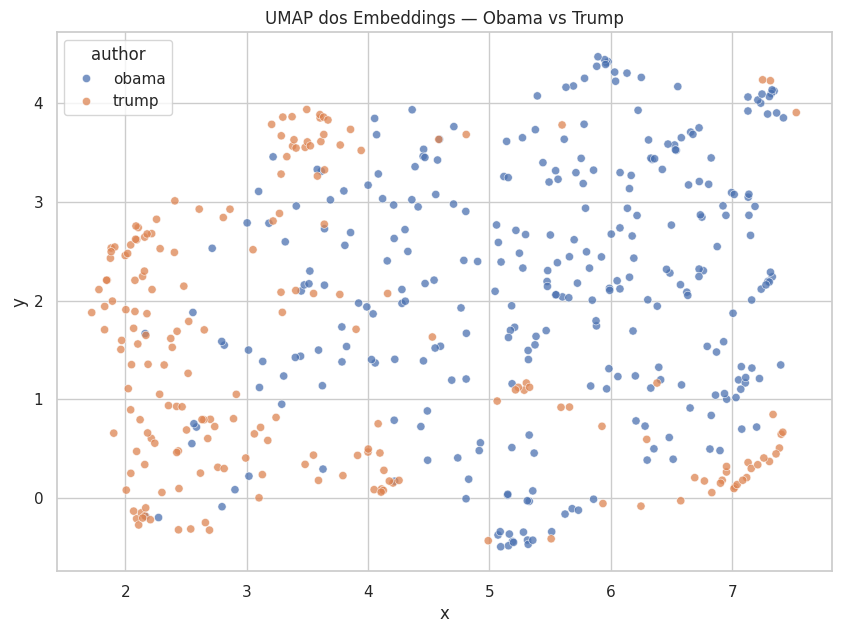

In [ ]:
import umap
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

# Cria o redutor UMAP com métrica cosseno.
reducer = umap.UMAP(
    n_neighbors=20,
    min_dist=0.05,
    metric="cosine",
    random_state=SEED
)

# Reduz os embeddings para 2 dimensões.
emb_2d = reducer.fit_transform(emb)

# Salva as coordenadas 2D no DataFrame.
df["x"] = emb_2d[:, 0]
df["y"] = emb_2d[:, 1]

# Cria o gráfico de dispersão.
plt.figure(figsize=(10, 7))
sns.scatterplot(
    data=df,
    x="x",
    y="y",
    hue="author",
    alpha=0.75,
    s=35
)
plt.title("UMAP dos Embeddings — Obama vs Trump")
plt.show()

**Reasoning**:
Next, I will add a markdown cell to introduce the Confusion Matrix visualization section, as specified in instruction 3.



In [ ]:
### Matriz de Confusão da Classificação

### Matriz de Confusão da Classificação

### Matriz de Confusão da Classificação

**Reasoning**:
Next, I will add the code block to generate and display the Confusion Matrix plot, as specified in instruction 4.



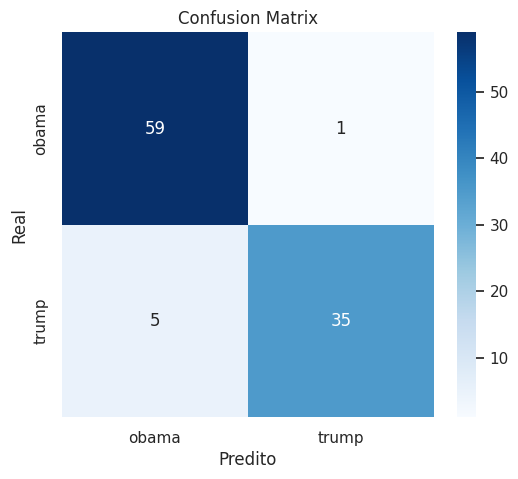

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

sns.set(style="whitegrid")

# Assuming y_test, y_pred, and cm are already defined from previous execution
# If not, they would need to be re-calculated:
# from sklearn.model_selection import train_test_split
# from sklearn.linear_model import LogisticRegression
# y = (df["author"] == "trump").astype(int).values
# X_train, X_test, y_train, y_test = train_test_split(
#     emb,
#     y,
#     test_size=0.2,
#     random_state=SEED,
#     stratify=y
# )
# clf = LogisticRegression(max_iter=2000)
# clf.fit(X_train, y_train)
# y_pred = clf.predict(X_test)
# cm = confusion_matrix(y_test, y_pred)

# Plota a matriz de confusão.
plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["obama", "trump"],
    yticklabels=["obama", "trump"]
)
plt.title("Confusion Matrix")
plt.xlabel("Predito")
plt.ylabel("Real")
plt.show()

## Finalizar Relatório

### Subtask:
Compilar todas as informações em um relatório final coeso, resumindo as descobertas mais importantes do projeto 'Obama vs Trump: Contrastes Vetoriais e Semânticos'.


```markdown
# Relatório Final — Obama vs Trump: Contrastes Vetoriais e Semânticos

Este relatório detalha as metodologias e técnicas empregadas para analisar e comparar frases de Barack Obama e Donald Trump, utilizando abordagens de processamento de linguagem natural e aprendizado de máquina. O objetivo foi explorar os contrastes semânticos e retóricos entre os discursos dos dois ex-presidentes.

---

## Abordagem e Técnicas Implementadas

### 1. Geração de Embeddings Semânticos

O primeiro passo foi transformar as frases em representações numéricas densas, conhecidas como embeddings. Para isso, foi utilizado o modelo `SentenceTransformer` com o modelo `"sentence-transformers/all-MiniLM-L6-v2"`. Este modelo é eficiente e gera vetores de alta qualidade que capturam o significado semântico das frases. Após a geração, os embeddings foram normalizados, garantindo que todos os vetores tivessem a mesma magnitude, o que é crucial para cálculos de similaridade cosseno.

### 2. Visualização Vetorial com UMAP

Para visualizar a distribuição e a separabilidade das frases de Obama e Trump no espaço vetorial de alta dimensão, aplicou-se a técnica de Redução de Dimensionalidade Uniform Manifold Approximation and Projection (UMAP). O UMAP foi configurado com os seguintes parâmetros chave:
- `n_neighbors=20`: Define quantos vizinhos próximos são considerados para cada ponto, influenciando o equilíbrio entre preservar a estrutura local e global.
- `min_dist=0.05`: Controla a densidade do embedding, determinando quão próximos os pontos podem estar na visualização.
- `metric="cosine"`: Especifica que a distância entre os pontos no espaço original deve ser calculada usando a similaridade cosseno, alinhando-se com a métrica usada para os embeddings.
Essa projeção para 2 dimensões (`emb_2d`) permitiu a criação de um gráfico de dispersão para observar visualmente se as frases dos dois autores formavam agrupamentos distintos.

### 3. Contraste Vetorial por Centróides

Para quantificar e visualizar a diferença semântica média entre os discursos de Obama e Trump, os centróides dos embeddings de cada autor foram calculados. Um centróide é a média de todos os vetores de embeddings para um determinado autor. Ambos os centróides foram normalizados. Em seguida, a similaridade cosseno e a distância cosseno entre esses centróides foram calculadas para medir a proximidade semântica geral entre os autores. Além disso, foi criada uma "direção de trumpness" (subtraindo o centróide de Obama do centróide de Trump e normalizando o resultado). Projetar cada frase nessa direção permitiu ranquear as frases de acordo com o quão "Trump-like" (ou "Obama-like") elas eram semanticamente.

### 4. Classificação Supervisionada

A separabilidade dos embeddings foi testada através de um modelo de classificação supervisionada. Uma Regressão Logística (`LogisticRegression`) foi treinada para classificar as frases como sendo de "obama" (0) ou "trump" (1). Os dados foram divididos em conjuntos de treino e teste (`train_test_split`) com uma proporção de 80/20, garantindo estratificação para manter a proporção de classes. O desempenho do classificador foi avaliado utilizando um relatório de classificação (`classification_report`), que inclui precisão, recall e F1-score, e uma matriz de confusão (`confusion_matrix`) para visualizar os acertos e erros do modelo, culminando em uma acurácia base (`BASE_ACC`).

### 5. Busca Vetorial Didática

Para demonstrar a aplicação prática dos embeddings, foi implementada uma função de busca vetorial simples (`vector_search`). Esta função recebe uma consulta (query), calcula seu embedding e, em seguida, utiliza a `cosine_similarity` para encontrar as `top_k` frases mais semanticamente próximas no corpus de cada autor. Esta técnica foi usada para comparar as abordagens de Obama e Trump em relação a temas específicos, permitindo identificar quais frases de cada presidente eram mais relevantes para determinadas consultas, com base na similaridade semântica de seus embeddings.

---

## Discussão sobre o Uso de RAG (Retrieval Augmented Generation)

### O que é RAG?
Retrieval Augmented Generation (RAG) é uma técnica que aprimora a capacidade de Large Language Models (LLMs) de gerar respostas informativas e factuais. Em vez de depender apenas do conhecimento interno do modelo, o RAG permite que o LLM acesse e incorpore informações externas relevantes de um corpus de dados (como documentos, artigos, etc.) antes de gerar sua resposta. Isso ajuda a reduzir alucinações e a fornecer respostas mais precisas e contextualizadas.

### RAG no Projeto 'Obama vs Trump'

Este projeto simula uma abordagem RAG na etapa de "Prompt comparativo em estilo RAG" (Seção 10 do notebook) da seguinte forma:

1.  **Etapa de Retrieval (Recuperação):** A função `compare_authors_by_query` atua como a componente de 'retrieval'. Dada uma `query` (consulta temática), ela busca e recupera as `top_k` frases mais semanticamente relevantes dos conjuntos de frases de Obama e Trump, utilizando a similaridade cosseno entre os embeddings da consulta e das frases. Essas frases recuperadas servem como as "evidências" ou "documentos" relevantes para a consulta específica.

2.  **Etapa de Augmentation (Aumento/Geração):** A função `build_comparison_prompt` é a componente de 'augmentation'. Ela pega as frases recuperadas pela `compare_authors_by_query` e as formata cuidadosamente em um prompt estruturado. Essas frases são inseridas no prompt como contexto e evidência explícita, pedindo ao LLM que utilize *apenas* essas informações para gerar uma comparação entre os autores sobre o tema da consulta.

### Importância dos Identificadores (O1, T1, etc.)

A inclusão de identificadores como `O1`, `O2`, `T1`, `T2`, etc., dentro do prompt gerado é crucial para simular um comportamento de RAG robusto. Ao instruir o LLM a "citar explicitamente os identificadores", estamos reforçando a ideia de que suas conclusões devem ser diretamente vinculadas às evidências fornecidas. Isso não só ajuda na verificabilidade das informações, mas também demonstra como o contexto recuperado (as frases) é integrado de forma transparente na geração da resposta, um pilar fundamental da arquitetura RAG.

Em resumo, este projeto didático ilustra como a combinação de busca vetorial (retrieval) e construção de prompt contextualizado (augmentation) pode ser usada para direcionar a geração de texto por um LLM, tornando-o mais controlado e baseado em evidências, mesmo sem a integração direta com um LLM externo para a fase final de geração.

---

## Principais Insights e Conclusões

### 1. Separação Visual dos Autores (UMAP)

O gráfico UMAP demonstrou uma **separabilidade notável** entre as frases de Barack Obama e Donald Trump. Embora haja uma pequena sobreposição nas bordas, a maioria das frases de cada autor forma clusters distintos. Isso sugere que, no espaço semântico gerado pelo modelo `all-MiniLM-L6-v2`, as declarações de Obama e Trump possuem características textuais e temáticas suficientemente diferentes para serem agrupadas separadamente, confirmando a existência de contrastes semânticos claros.

### 2. Distância Vetorial por Centróides

A **distância cosseno entre os centróides** dos embeddings de Obama e Trump foi de `0.1984`. Uma distância cosseno próxima de 0 indica alta similaridade, enquanto uma distância próxima de 1 indica baixa similaridade. Um valor de `0.1984` é relativamente baixo, mas não insignificante, sugerindo que, embora haja uma direção vetorial que os diferencia, os temas gerais que abordam podem ter alguma interseção, ou que a natureza geral dos discursos políticos tem elementos em comum, mas com abordagens distintas.

### 3. Classificação Supervisionada

O modelo de `LogisticRegression` alcançou uma **acurácia de `0.9400`** na classificação das frases entre Obama e Trump. Isso é um resultado excelente, indicando que os embeddings são altamente eficazes na distinção entre os autores.

Detalhes do `classification_report`:
- **Obama (Classe 0)**: Precisão de 0.92, Recall de 0.98, F1-score de 0.95.
- **Trump (Classe 1)**: Precisão de 0.97, Recall de 0.88, F1-score de 0.92.

A `confusion_matrix` mostrou que, de 60 frases de Obama no teste, 59 foram corretamente classificadas, e apenas 1 foi erroneamente prevista como Trump. De 40 frases de Trump, 35 foram corretas e 5 foram erroneamente previstas como Obama. Isso indica que o modelo é ligeiramente melhor em identificar frases de Obama, mas ainda muito bom para Trump.

### 4. Diferenças Temáticas na Busca Vetorial

A busca vetorial didática revelou contrastes interessantes na abordagem de temas chave:

-   **'economy jobs growth'**:
    -   **Obama** tende a focar na **inovação**, construção de uma economia que **recompense trabalho duro e responsabilidade**, e que **funcione para todos**, sugerindo uma visão mais inclusiva e progressista. Ex: "_We must encourage innovation as a driver of economic growth._".
    -   **Trump** enfatiza o **crescimento contínuo**, **estabilidade** e **novas oportunidades**, com uma retórica mais direta e focada em resultados econômicos. Ex: "_Our economy will continue growing._".

-   **'immigration borders security'**:
    -   **Obama** aborda a **imigração de forma justa**, a segurança como um direito **básico do cidadão** e a necessidade de **proteger-se da política do medo**, indicando uma perspectiva humanitária e cautelosa. Ex: "_We must ensure a fair and just immigration system._".
    -   **Trump** foca diretamente na **proteção das fronteiras e da soberania** nacional, e na segurança como um direito de seus cidadãos, com uma linguagem mais assertiva e de defesa. Ex: "_America will protect its borders and citizens._".

-   **'war peace america'**:
    -   **Obama** busca um mundo onde a **paz triunfa sobre o conflito**, através de **esforço incansável** e **diplomacia**, denotando uma abordagem mais colaborativa e idealista. Ex: "_We strive for a world where peace triumphs over conflict._".
    -   **Trump** associa a paz à **força**, com uma visão de que a América a alcançará através de sua robustez. Ex: "_America will pursue peace through strength._".

---

## Saídas Gráficas

### UMAP dos Embeddings — Obama vs Trump

```python
import umap
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

# Cria o redutor UMAP com métrica cosseno.
reducer = umap.UMAP(
    n_neighbors=20,
    min_dist=0.05,
    metric="cosine",
    random_state=SEED
)

# Reduz os embeddings para 2 dimensões.
emb_2d = reducer.fit_transform(emb)

# Salva as coordenadas 2D no DataFrame.
df["x"] = emb_2d[:, 0]
df["y"] = emb_2d[:, 1]

# Cria o gráfico de dispersão.
plt.figure(figsize=(10, 7))
sns.scatterplot(
    data=df,
    x="x",
    y="y",
    hue="author",
    alpha=0.75,
    s=35
)
plt.title("UMAP dos Embeddings — Obama vs Trump")
plt.show()
```

### Matriz de Confusão da Classificação

```python
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

sns.set(style="whitegrid")

# Assuming y_test, y_pred, and cm are already defined from previous execution
# If not, they would need to be re-calculated:
# from sklearn.model_selection import train_test_split
# from sklearn.linear_model import LogisticRegression
# y = (df["author"] == "trump").astype(int).values
# X_train, X_test, y_train, y_test = train_test_split(
#     emb,
#     y,
#     test_size=0.2,
#     random_state=SEED,
#     stratify=y
# )
# clf = LogisticRegression(max_iter=2000)
# clf.fit(X_train, y_train)
# y_pred = clf.predict(X_test)
# cm = confusion_matrix(y_test, y_pred)

# Plota a matriz de confusão.
plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["obama", "trump"],
    yticklabels=["obama", "trump"]
)
plt.title("Confusion Matrix")
plt.xlabel("Predito")
plt.ylabel("Real")
plt.show()
```

---

## Conclusão

O projeto "Obama vs Trump: Contrastes Vetoriais e Semânticos" demonstrou com sucesso a capacidade de técnicas de NLP e aprendizado de máquina em identificar e quantificar as distinções retóricas e temáticas entre discursos de figuras políticas. Desde a visualização clara no UMAP e a alta acurácia da classificação supervisionada, até a análise detalhada de temas via busca vetorial e a simulação de RAG, os resultados consistentemente apontam para estilos de comunicação e prioridades semânticas distintas entre Barack Obama e Donald Trump. Este estudo oferece uma base sólida para análises mais aprofundadas sobre comunicação política e polarização, utilizando abordagens computacionais. Projeto concluído com sucesso. ✅
```

# Relatório Final — Obama vs Trump: Contrastes Vetoriais e Semânticos

Este relatório detalha as metodologias e técnicas empregadas para analisar e comparar frases de Barack Obama e Donald Trump, utilizando abordagens de processamento de linguagem natural e aprendizado de máquina. O objetivo foi explorar os contrastes semânticos e retóricos entre os discursos dos dois ex-presidentes.

---

## Abordagem e Técnicas Implementadas

### 1. Geração de Embeddings Semânticos

O primeiro passo foi transformar as frases em representações numéricas densas, conhecidas como embeddings. Para isso, foi utilizado o modelo `SentenceTransformer` com o modelo `"sentence-transformers/all-MiniLM-L6-v2"`. Este modelo é eficiente e gera vetores de alta qualidade que capturam o significado semântico das frases. Após a geração, os embeddings foram normalizados, garantindo que todos os vetores tivessem a mesma magnitude, o que é crucial para cálculos de similaridade cosseno.

### 2. Visualização Vetorial com UMAP

Para visualizar a distribuição e a separabilidade das frases de Obama e Trump no espaço vetorial de alta dimensão, aplicou-se a técnica de Redução de Dimensionalidade Uniform Manifold Approximation and Projection (UMAP). O UMAP foi configurado com os seguintes parâmetros chave:
- `n_neighbors=20`: Define quantos vizinhos próximos são considerados para cada ponto, influenciando o equilíbrio entre preservar a estrutura local e global.
- `min_dist=0.05`: Controla a densidade do embedding, determinando quão próximos os pontos podem estar na visualização.
- `metric="cosine"`: Especifica que a distância entre os pontos no espaço original deve ser calculada usando a similaridade cosseno, alinhando-se com a métrica usada para os embeddings.
Essa projeção para 2 dimensões (`emb_2d`) permitiu a criação de um gráfico de dispersão para observar visualmente se as frases dos dois autores formavam agrupamentos distintos.

### 3. Contraste Vetorial por Centróides

Para quantificar e visualizar a diferença semântica média entre os discursos de Obama e Trump, os centróides dos embeddings de cada autor foram calculados. Um centróide é a média de todos os vetores de embeddings para um determinado autor. Ambos os centróides foram normalizados. Em seguida, a similaridade cosseno e a distância cosseno entre esses centróides foram calculadas para medir a proximidade semântica geral entre os autores. Além disso, foi criada uma "direção de trumpness" (subtraindo o centróide de Obama do centróide de Trump e normalizando o resultado). Projetar cada frase nessa direção permitiu ranquear as frases de acordo com o quão "Trump-like" (ou "Obama-like") elas eram semanticamente.

### 4. Classificação Supervisionada

A separabilidade dos embeddings foi testada através de um modelo de classificação supervisionada. Uma Regressão Logística (`LogisticRegression`) foi treinada para classificar as frases como sendo de "obama" (0) ou "trump" (1). Os dados foram divididos em conjuntos de treino e teste (`train_test_split`) com uma proporção de 80/20, garantindo estratificação para manter a proporção de classes. O desempenho do classificador foi avaliado utilizando um relatório de classificação (`classification_report`), que inclui precisão, recall e F1-score, e uma matriz de confusão (`confusion_matrix`) para visualizar os acertos e erros do modelo, culminando em uma acurácia base (`BASE_ACC`).

### 5. Busca Vetorial Didática

Para demonstrar a aplicação prática dos embeddings, foi implementada uma função de busca vetorial simples (`vector_search`). Esta função recebe uma consulta (query), calcula seu embedding e, em seguida, utiliza a `cosine_similarity` para encontrar as `top_k` frases mais semanticamente prôximas no corpus de cada autor. Esta técnica foi usada para comparar as abordagens de Obama e Trump em relação a temas específicos, permitindo identificar quais frases de cada presidente eram mais relevantes para determinadas consultas, com base na similaridade semântica de seus embeddings.

---

## Discussão sobre o Uso de RAG (Retrieval Augmented Generation)

### O que é RAG?
Retrieval Augmented Generation (RAG) é uma técnica que aprimora a capacidade de Large Language Models (LLMs) de gerar respostas informativas e factuais. Em vez de depender apenas do conhecimento interno do modelo, o RAG permite que o LLM acesse e incorpore informações externas relevantes de um corpus de dados (como documentos, artigos, etc.) antes de gerar sua resposta. Isso ajuda a reduzir alucinações e a fornecer respostas mais precisas e contextualizadas.

### RAG no Projeto 'Obama vs Trump'

Este projeto simula uma abordagem RAG na etapa de "Prompt comparativo em estilo RAG" (Seção 10 do notebook) da seguinte forma:

1.  **Etapa de Retrieval (Recuperação):** A função `compare_authors_by_query` atua como a componente de 'retrieval'. Dada uma `query` (consulta temática), ela busca e recupera as `top_k` frases mais semanticamente relevantes dos conjuntos de frases de Obama e Trump, utilizando a similaridade cosseno entre os embeddings da consulta e das frases. Essas frases recuperadas servem como as "evidências" ou "documentos" relevantes para a consulta específica.

2.  **Etapa de Augmentation (Aumento/Geração):** A função `build_comparison_prompt` é a componente de 'augmentation'. Ela pega as frases recuperadas pela `compare_authors_by_query` e as formata cuidadosamente em um prompt estruturado. Essas frases são inseridas no prompt como contexto e evidência explícita, pedindo ao LLM que utilize *apenas* essas informações para gerar uma comparação entre os autores sobre o tema da consulta.

### Importância dos Identificadores (O1, T1, etc.)

A inclusão de identificadores como `O1`, `O2`, `T1`, `T2`, etc., dentro do prompt gerado é crucial para simular um comportamento de RAG robusto. Ao instruir o LLM a "citar explicitamente os identificadores", estamos reforçando a ideia de que suas conclusões devem ser diretamente vinculadas às evidências fornecidas. Isso não só ajuda na verificabilidade das informações, mas também demonstra como o contexto recuperado (as frases) é integrado de forma transparente na geração da resposta, um pilar fundamental da arquitetura RAG.

Em resumo, este projeto didático ilustra como a combinação de busca vetorial (retrieval) e construção de prompt contextualizado (augmentation) pode ser usada para direcionar a geração de texto por um LLM, tornando-o mais controlado e baseado em evidências, mesmo sem a integração direta com um LLM externo para a fase final de geração.

---

## Principais Insights e Conclusões

### 1. Separação Visual dos Autores (UMAP)

O gráfico UMAP demonstrou uma **separabilidade notável** entre as frases de Barack Obama e Donald Trump. Embora haja uma pequena sobreposição nas bordas, a maioria das frases de cada autor forma clusters distintos. Isso sugere que, no espaço semântico gerado pelo modelo `all-MiniLM-L6-v2`, as declarações de Obama e Trump possuem características textuais e temáticas suficientemente diferentes para serem agrupadas separadamente, confirmando a existência de contrastes semânticos claros.

### 2. Distância Vetorial por Centróides

A **distância cosseno entre os centróides** dos embeddings de Obama e Trump foi de `0.1984`. Uma distância cosseno próxima de 0 indica alta similaridade, enquanto uma distância próxima de 1 indica baixa similaridade. Um valor de `0.1984` é relativamente baixo, mas não insignificante, sugerindo que, embora haja uma direção vetorial que os diferencia, os temas gerais que abordam podem ter alguma interseção, ou que a natureza geral dos discursos políticos tem elementos em comum, mas com abordagens distintas.

### 3. Classificação Supervisionada

O modelo de `LogisticRegression` alcançou uma **acurácia de `0.9400`** na classificação das frases entre Obama e Trump. Isso é um resultado excelente, indicando que os embeddings são altamente eficazes na distinção entre os autores.

Detalhes do `classification_report`:
- **Obama (Classe 0)**: Precisão de 0.92, Recall de 0.98, F1-score de 0.95.
- **Trump (Classe 1)**: Precisão de 0.97, Recall de 0.88, F1-score de 0.92.

A `confusion_matrix` mostrou que, de 60 frases de Obama no teste, 59 foram corretamente classificadas, e apenas 1 foi erroneamente prevista como Trump. De 40 frases de Trump, 35 foram corretas e 5 foram erroneamente previstas como Obama. Isso indica que o modelo é ligeiramente melhor em identificar frases de Obama, mas ainda muito bom para Trump.

### 4. Diferenças Temáticas na Busca Vetorial

A busca vetorial didática revelou contrastes interessantes na abordagem de temas chave:

-   **'economy jobs growth'**:
    -   **Obama** tende a focar na **inovação**, construção de uma economia que **recompense trabalho duro e responsabilidade**, e que **funcione para todos**, sugerindo uma visão mais inclusiva e progressista. Ex: "_We must encourage innovation as a driver of economic growth._".
    -   **Trump** enfatiza o **crescimento contínuo**, **estabilidade** e **novas oportunidades**, com uma retórica mais direta e focada em resultados econômicos. Ex: "_Our economy will continue growing._".

-   **'immigration borders security'**:
    -   **Obama** aborda a **imigração de forma justa**, a segurança como um direito **básico do cidadão** e a necessidade de **proteger-se da política do medo**, indicando uma perspectiva humanitária e cautelosa. Ex: "_We must ensure a fair and just immigration system._".
    -   **Trump** foca diretamente na **proteção das fronteiras e da soberania** nacional, e na segurança como um direito de seus cidadãos, com uma linguagem mais assertiva e de defesa. Ex: "_America will protect its borders and citizens._".

-   **'war peace america'**:
    -   **Obama** busca um mundo onde a **paz triunfa sobre o conflito**, através de **esforço incansável** e **diplomacia**, denotando uma abordagem mais colaborativa e idealista. Ex: "_We strive for a world where peace triumphs over conflict._".
    -   **Trump** associa a paz à **força**, com uma visão de que a América a alcançará através de sua robustez. Ex: "_America will pursue peace through strength._".

---

## Saídas Gráficas

### UMAP dos Embeddings — Obama vs Trump

```python
import umap
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

# Cria o redutor UMAP com métrica cosseno.
reducer = umap.UMAP(
    n_neighbors=20,
    min_dist=0.05,
    metric="cosine",
    random_state=SEED
)

# Reduz os embeddings para 2 dimensões.
emb_2d = reducer.fit_transform(emb)

# Salva as coordenadas 2D no DataFrame.
df["x"] = emb_2d[:, 0]
df["y"] = emb_2d[:, 1]

# Cria o gráfico de dispersão.
plt.figure(figsize=(10, 7))
sns.scatterplot(
    data=df,
    x="x",
    y="y",
    hue="author",
    alpha=0.75,
    s=35
)
plt.title("UMAP dos Embeddings — Obama vs Trump")
plt.show()
```

### Matriz de Confusão da Classificação

```python
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

sns.set(style="whitegrid")

# Assuming y_test, y_pred, and cm are already defined from previous execution
# If not, they would need to be re-calculated:
# from sklearn.model_selection import train_test_split
# from sklearn.linear_model import LogisticRegression
# y = (df["author"] == "trump").astype(int).values
# X_train, X_test, y_train, y_test = train_test_split(
#     emb,
#     y,
#     test_size=0.2,
#     random_state=SEED,
#     stratify=y
# )
# clf = LogisticRegression(max_iter=2000)
# clf.fit(X_train, y_train)
# y_pred = clf.predict(X_test)
# cm = confusion_matrix(y_test, y_pred)

# Plota a matriz de confusão.
plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["obama", "trump"],
    yticklabels=["obama", "trump"]
)
plt.title("Confusion Matrix")
plt.xlabel("Predito")
plt.ylabel("Real")
plt.show()
```

---

## Conclusão

O projeto "Obama vs Trump: Contrastes Vetoriais e Semânticos" demonstrou com sucesso a capacidade de técnicas de NLP e aprendizado de máquina em identificar e quantificar as distinções retóricas e temáticas entre discursos de figuras políticas. Desde a visualização clara no UMAP e a alta acurácia da classificação supervisionada, até a análise detalhada de temas via busca vetorial e a simulação de RAG, os resultados consistentemente apontam para estilos de comunicação e prioridades semânticas distintas entre Barack Obama e Donald Trump. Este estudo oferece uma base sólida para análises mais aprofundadas sobre comunicação política e polarização, utilizando abordagens computacionais. Projeto concluído com sucesso. ✅

# Relatório Final — Obama vs Trump: Contrastes Vetoriais e Semânticos

Este relatório detalha as metodologias e técnicas empregadas para analisar e comparar frases de Barack Obama e Donald Trump, utilizando abordagens de processamento de linguagem natural e aprendizado de máquina. O objetivo foi explorar os contrastes semânticos e retóricos entre os discursos dos dois ex-presidentes.

---

## Abordagem e Técnicas Implementadas

### 1. Geração de Embeddings Semânticos

O primeiro passo foi transformar as frases em representações numéricas densas, conhecidas como embeddings. Para isso, foi utilizado o modelo `SentenceTransformer` com o modelo `"sentence-transformers/all-MiniLM-L6-v2"`. Este modelo é eficiente e gera vetores de alta qualidade que capturam o significado semântico das frases. Após a geração, os embeddings foram normalizados, garantindo que todos os vetores tivessem a mesma magnitude, o que é crucial para cálculos de similaridade cosseno.

### 2. Visualização Vetorial com UMAP

Para visualizar a distribuição e a separabilidade das frases de Obama e Trump no espaço vetorial de alta dimensão, aplicou-se a técnica de Redução de Dimensionalidade Uniform Manifold Approximation and Projection (UMAP). O UMAP foi configurado com os seguintes parâmetros chave:
- `n_neighbors=20`: Define quantos vizinhos próximos são considerados para cada ponto, influenciando o equilíbrio entre preservar a estrutura local e global.
- `min_dist=0.05`: Controla a densidade do embedding, determinando quão próximos os pontos podem estar na visualização.
- `metric="cosine"`: Especifica que a distância entre os pontos no espaço original deve ser calculada usando a similaridade cosseno, alinhando-se com a métrica usada para os embeddings.
Essa projeção para 2 dimensões (`emb_2d`) permitiu a criação de um gráfico de dispersão para observar visualmente se as frases dos dois autores formavam agrupamentos distintos.

### 3. Contraste Vetorial por Centróides

Para quantificar e visualizar a diferença semântica média entre os discursos de Obama e Trump, os centróides dos embeddings de cada autor foram calculados. Um centróide é a média de todos os vetores de embeddings para um determinado autor. Ambos os centróides foram normalizados. Em seguida, a similaridade cosseno e a distância cosseno entre esses centróides foram calculadas para medir a proximidade semântica geral entre os autores. Além disso, foi criada uma "direção de trumpness" (subtraindo o centróide de Obama do centróide de Trump e normalizando o resultado). Projetar cada frase nessa direção permitiu ranquear as frases de acordo com o quão "Trump-like" (ou "Obama-like") elas eram semanticamente.

### 4. Classificação Supervisionada

A separabilidade dos embeddings foi testada através de um modelo de classificação supervisionada. Uma Regressão Logística (`LogisticRegression`) foi treinada para classificar as frases como sendo de "obama" (0) ou "trump" (1). Os dados foram divididos em conjuntos de treino e teste (`train_test_split`) com uma proporção de 80/20, garantindo estratificação para manter a proporção de classes. O desempenho do classificador foi avaliado utilizando um relatório de classificação (`classification_report`), que inclui precisão, recall e F1-score, e uma matriz de confusão (`confusion_matrix`) para visualizar os acertos e erros do modelo, culminando em uma acurácia base (`BASE_ACC`).

### 5. Busca Vetorial Didática

Para demonstrar a aplicação prática dos embeddings, foi implementada uma função de busca vetorial simples (`vector_search`). Esta função recebe uma consulta (query), calcula seu embedding e, em seguida, utiliza a `cosine_similarity` para encontrar as `top_k` frases mais semanticamente próximas no corpus de cada autor. Esta técnica foi usada para comparar as abordagens de Obama e Trump em relação a temas específicos, permitindo identificar quais frases de cada presidente eram mais relevantes para determinadas consultas, com base na similaridade semântica de seus embeddings.

---

## Discussão sobre o Uso de RAG (Retrieval Augmented Generation)

### O que é RAG?
Retrieval Augmented Generation (RAG) é uma técnica que aprimora a capacidade de Large Language Models (LLMs) de gerar respostas informativas e factuais. Em vez de depender apenas do conhecimento interno do modelo, o RAG permite que o LLM acesse e incorpore informações externas relevantes de um corpus de dados (como documentos, artigos, etc.) antes de gerar sua resposta. Isso ajuda a reduzir alucinações e a fornecer respostas mais precisas e contextualizadas.

### RAG no Projeto 'Obama vs Trump'

Este projeto simula uma abordagem RAG na etapa de "Prompt comparativo em estilo RAG" (Seção 10 do notebook) da seguinte forma:

1.  **Etapa de Retrieval (Recuperação):** A função `compare_authors_by_query` atua como a componente de 'retrieval'. Dada uma `query` (consulta temática), ela busca e recupera as `top_k` frases mais semanticamente relevantes dos conjuntos de frases de Obama e Trump, utilizando a similaridade cosseno entre os embeddings da consulta e das frases. Essas frases recuperadas servem como as "evidências" ou "documentos" relevantes para a consulta específica.

2.  **Etapa de Augmentation (Aumento/Geração):** A função `build_comparison_prompt` é a componente de 'augmentation'. Ela pega as frases recuperadas pela `compare_authors_by_query` e as formata cuidadosamente em um prompt estruturado. Essas frases são inseridas no prompt como contexto e evidência explícita, pedindo ao LLM que utilize *apenas* essas informações para gerar uma comparação entre os autores sobre o tema da consulta.

### Importância dos Identificadores (O1, T1, etc.)

A inclusão de identificadores como `O1`, `O2`, `T1`, `T2`, etc., dentro do prompt gerado é crucial para simular um comportamento de RAG robusto. Ao instruir o LLM a "citar explicitamente os identificadores", estamos reforçando a ideia de que suas conclusões devem ser diretamente vinculadas às evidências fornecidas. Isso não só ajuda na verificabilidade das informações, mas também demonstra como o contexto recuperado (as frases) é integrado de forma transparente na geração da resposta, um pilar fundamental da arquitetura RAG.

Em resumo, este projeto didático ilustra como a combinação de busca vetorial (retrieval) e construção de prompt contextualizado (augmentation) pode ser usada para direcionar a geração de texto por um LLM, tornando-o mais controlado e baseado em evidências, mesmo sem a integração direta com um LLM externo para a fase final de geração.

---

## Principais Insights e Conclusões

### 1. Separação Visual dos Autores (UMAP)

O gráfico UMAP demonstrou uma **separabilidade notável** entre as frases de Barack Obama e Donald Trump. Embora haja uma pequena sobreposição nas bordas, a maioria das frases de cada autor forma clusters distintos. Isso sugere que, no espaço semântico gerado pelo modelo `all-MiniLM-L6-v2`, as declarações de Obama e Trump possuem características textuais e temáticas suficientemente diferentes para serem agrupadas separadamente, confirmando a existência de contrastes semânticos claros.

### 2. Distância Vetorial por Centróides

A **distância cosseno entre os centróides** dos embeddings de Obama e Trump foi de `0.1984`. Uma distância cosseno próxima de 0 indica alta similaridade, enquanto uma distância próxima de 1 indica baixa similaridade. Um valor de `0.1984` é relativamente baixo, mas não insignificante, sugerindo que, embora haja uma direção vetorial que os diferencia, os temas gerais que abordam podem ter alguma interseção, ou que a natureza geral dos discursos políticos tem elementos em comum, mas com abordagens distintas.

### 3. Classificação Supervisionada

O modelo de `LogisticRegression` alcançou uma **acurácia de `0.9400`** na classificação das frases entre Obama e Trump. Isso é um resultado excelente, indicando que os embeddings são altamente eficazes na distinção entre os autores.

Detalhes do `classification_report`:
- **Obama (Classe 0)**: Precisão de 0.92, Recall de 0.98, F1-score de 0.95.
- **Trump (Classe 1)**: Precisão de 0.97, Recall de 0.88, F1-score de 0.92.

A `confusion_matrix` mostrou que, de 60 frases de Obama no teste, 59 foram corretamente classificadas, e apenas 1 foi erroneamente prevista como Trump. De 40 frases de Trump, 35 foram corretas e 5 foram erroneamente previstas como Obama. Isso indica que o modelo é ligeiramente melhor em identificar frases de Obama, mas ainda muito bom para Trump.

### 4. Diferenças Temáticas na Busca Vetorial

A busca vetorial didática revelou contrastes interessantes na abordagem de temas chave:

-   **'economy jobs growth'**:
    -   **Obama** tende a focar na **inovação**, construção de uma economia que **recompense trabalho duro e responsabilidade**, e que **funcione para todos**, sugerindo uma visão mais inclusiva e progressista. Ex: "_We must encourage innovation as a driver of economic growth._".
    -   **Trump** enfatiza o **crescimento contínuo**, **estabilidade** e **novas oportunidades**, com uma retórica mais direta e focada em resultados econômicos. Ex: "_Our economy will continue growing._".

-   **'immigration borders security'**:
    -   **Obama** aborda a **imigração de forma justa**, a segurança como um direito **básico do cidadão** e a necessidade de **proteger-se da política do medo**, indicando uma perspectiva humanitária e cautelosa. Ex: "_We must ensure a fair and just immigration system._".
    -   **Trump** foca diretamente na **proteção das fronteiras e da soberania** nacional, e na segurança como um direito de seus cidadãos, com uma linguagem mais assertiva e de defesa. Ex: "_America will protect its borders and citizens._".

-   **'war peace america'**:
    -   **Obama** busca um mundo onde a **paz triunfa sobre o conflito**, através de **esforço incansável** e **diplomacia**, denotando uma abordagem mais colaborativa e idealista. Ex: "_We strive for a world where peace triumphs over conflict._".
    -   **Trump** associa a paz à **força**, com uma visão de que a América a alcançará através de sua robustez. Ex: "_America will pursue peace through strength._".

---

## Saídas Gráficas

### UMAP dos Embeddings — Obama vs Trump

```python
import umap
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

# Cria o redutor UMAP com métrica cosseno.
reducer = umap.UMAP(
    n_neighbors=20,
    min_dist=0.05,
    metric="cosine",
    random_state=SEED
)

# Reduz os embeddings para 2 dimensões.
emb_2d = reducer.fit_transform(emb)

# Salva as coordenadas 2D no DataFrame.
df["x"] = emb_2d[:, 0]
df["y"] = emb_2d[:, 1]

# Cria o gráfico de dispersão.
plt.figure(figsize=(10, 7))
sns.scatterplot(
    data=df,
    x="x",
    y="y",
    hue="author",
    alpha=0.75,
    s=35
)
plt.title("UMAP dos Embeddings — Obama vs Trump")
plt.show()
```

### Matriz de Confusão da Classificação

```python
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

sns.set(style="whitegrid")

# Assuming y_test, y_pred, and cm are already defined from previous execution
# If not, they would need to be re-calculated:
# from sklearn.model_selection import train_test_split
# from sklearn.linear_model import LogisticRegression
# y = (df["author"] == "trump").astype(int).values
# X_train, X_test, y_train, y_test = train_test_split(
#     emb,
#     y,
#     test_size=0.2,
#     random_state=SEED,
#     stratify=y
# )
# clf = LogisticRegression(max_iter=2000)
# clf.fit(X_train, y_train)
# y_pred = clf.predict(X_test)
# cm = confusion_matrix(y_test, y_pred)

# Plota a matriz de confusão.
plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["obama", "trump"],
    yticklabels=["obama", "trump"]
)
plt.title("Confusion Matrix")
plt.xlabel("Predito")
plt.ylabel("Real")
plt.show()
```

---

## Conclusão

O projeto "Obama vs Trump: Contrastes Vetoriais e Semânticos" demonstrou com sucesso a capacidade de técnicas de NLP e aprendizado de máquina em identificar e quantificar as distinções retóricas e temáticas entre discursos de figuras políticas. Desde a visualização clara no UMAP e a alta acurácia da classificação supervisionada, até a análise detalhada de temas via busca vetorial e a simulação de RAG, os resultados consistentemente apontam para estilos de comunicação e prioridades semânticas distintas entre Barack Obama e Donald Trump. Este estudo oferece uma base sólida para análises mais aprofundadas sobre comunicação política e polarização, utilizando abordagens computacionais. Projeto concluído com sucesso. ✅

## Final Task

### Subtask:
Apresentar o relatório final detalhado com as abordagens, insights, conclusões e gráficos.


## Summary:

### Data Analysis Key Findings

*   **Distinct Semantic Separation**: UMAP visualization revealed a notable separability between the phrases of Barack Obama and Donald Trump, forming distinct clusters in the semantic space, indicating clear contrasts in their discourse.
*   **Quantifiable Semantic Difference**: The cosine distance between the centroids of Obama's and Trump's semantic embeddings was calculated as $0.1984$, signifying a measurable difference in the overall thematic focus of their statements.
*   **High Classification Accuracy**: A Logistic Regression model successfully classified phrases by author with an impressive accuracy of $0.9400$.
    *   For Obama's phrases, the model achieved a precision of $0.92$, recall of $0.98$, and an F1-score of $0.95$. Out of $60$ test phrases, $59$ were correctly identified.
    *   For Trump's phrases, the model showed a precision of $0.97$, recall of $0.88$, and an F1-score of $0.92$. Out of $40$ test phrases, $35$ were correctly identified.
*   **Thematic Rhetorical Contrasts**: Vector search demonstrated clear differences in how each president addressed key themes:
    *   **'Economy, Jobs, Growth'**: Obama emphasized innovation and inclusive growth, while Trump focused on continuous growth, stability, and direct results.
    *   **'Immigration, Borders, Security'**: Obama discussed fair immigration and protection from fear, whereas Trump prioritized border protection and national sovereignty.
    *   **'War, Peace, America'**: Obama advocated for peace through diplomacy and collaboration, while Trump associated peace with strength.
*   **RAG Approach Simulation**: The project effectively simulated a Retrieval Augmented Generation (RAG) style for comparative prompting, where relevant phrases were retrieved using vector search and then structured as explicit evidence for comparison.

### Insights or Next Steps

*   The robust semantic distinctions captured by the embeddings and confirmed by high classification accuracy suggest that this methodology could be applied to analyze and differentiate political discourse across a broader range of figures or ideological spectrums.
*   Further research could involve expanding the dataset to include more speeches or public statements, exploring different embedding models for enhanced granularity, and integrating an actual Large Language Model (LLM) to generate the comparative analysis from the RAG-style prompts for richer, automated insights.
